## Tiny SQL Development  

### Set up

#### Install depdenence Library

In [ ]:
!apt-get update
!apt-get install -y gettext-base

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://packages.cloud.google.com/apt gcsfuse-jammy InRelease [1,227 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://packages.cloud.google.com/apt gcsfuse-jammy/main amd64 Packages [59.6 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,436 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes

In [ ]:
!pip install -q sqlglot pyyaml datasets seaborn python-dotenv sqlalchemy>=2.0 pyyaml --extra-index-url https://pypi.org/simple   --no-warn-script-location

#### Import Libraries

In [ ]:
import os
import sys
import dotenv
import json
import logging
import sqlglot
import random
import yaml
import copy

project_dir=f'/content/aai-590-tinysql'
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
    sys.path.insert(1, f"{project_dir}/src")

os.environ['PROJECT_DIR'] = project_dir

if os.path.exists(f'{project_dir}/env.txt'):
    dotenv.load_dotenv(f"{project_dir}/env.txt")
else:
    print("Env file does not exist.")

In [ ]:
import sys
import os

# Ensure project_dir is defined, as it's used to construct the path
project_dir=f'/content/aai-590-tinysql'

# Add the src directory to sys.path to ensure local modules are found
if f"{project_dir}/src" not in sys.path:
    sys.path.insert(0, f"{project_dir}/src")

from datasets import load_dataset
from huggingface_hub import login

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

from util.config_loader import config_loader

logging.getLogger("datasets").setLevel(logging.ERROR)
logging.getLogger("sqlglot").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


### Data Ingestion

In [ ]:
hf_token=os.getenv("HF_TOKEN")

In [ ]:
# Explicitly log in to Hugging Face Hub
login(token=hf_token)

In [ ]:
ds = load_dataset("gretelai/synthetic_text_to_sql", split="train")
raw_subset = ds.select(range(50000))

README.md: 0.00B [00:00, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…):   0%|          | 0.00/32.4M [00:00<?, ?B/s]

synthetic_text_to_sql_test.snappy.parque(…):   0%|          | 0.00/1.90M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5851 [00:00<?, ? examples/s]

In [ ]:
test_ds = load_dataset("gretelai/synthetic_text_to_sql", split="test")
tinycode_test_ds = test_ds.select(range(5000))
print (tinycode_test_ds[0])


{'id': 1, 'domain': 'artificial intelligence', 'domain_description': 'AI data on algorithmic fairness, AI safety, explainable AI, and creative AI applications.', 'sql_complexity': 'basic SQL', 'sql_complexity_description': 'basic SQL with a simple select statement', 'sql_task_type': 'analytics and reporting', 'sql_task_type_description': 'generating reports, dashboards, and analytical insights', 'sql_prompt': "What is the average explainability score of creative AI applications in 'Europe' and 'North America' in the 'creative_ai' table?", 'sql_context': "CREATE TABLE creative_ai (application_id INT, name TEXT, region TEXT, explainability_score FLOAT); INSERT INTO creative_ai (application_id, name, region, explainability_score) VALUES (1, 'ApplicationX', 'Europe', 0.87), (2, 'ApplicationY', 'North America', 0.91), (3, 'ApplicationZ', 'Europe', 0.84), (4, 'ApplicationAA', 'North America', 0.93), (5, 'ApplicationAB', 'Europe', 0.89);", 'sql': "SELECT AVG(explainability_score) FROM creativ

### Preprocessing & Visualizations

In [ ]:
def apply_tinycode_logic(example):
    original_sql = example['sql']
    schema = example['sql_context']
    question = example['sql_prompt']
    explanation = example['sql_explanation']

    # --- LAYER 1 & 3: Dialect Transpilation & BQ Normalization ---
    try:
        # Transpile to BigQuery and force backticks (identify=True)
        bq_sql = sqlglot.transpile(original_sql, read=None, write="bigquery", identify=True)[0]

        # BQ Normalization: SAFE_CAST and QUALIFY
        # (Example: replace risky CASTs with SAFE_CAST)
        bq_sql = bq_sql.replace("CAST(", "SAFE_CAST(").replace("cast(", "safe_cast(")
    except:
        bq_sql = original_sql

    # --- LAYER 2: Schema Pruning (Negative Sampling) ---
    # In 20% of cases, we add a "distractor" table to the schema
    if random.random() < 0.20:
        distractor = "\nCREATE TABLE `irrelevant_metadata` (id INT64, log_date DATE, notes STRING);"
        schema = schema + distractor

    # --- LAYER 4: Sample Row Injection (Value Grounding) ---
    # We simulate sample rows to help the model understand data values
    # In a real project, you'd pull these from the DB. Here we inject a hint.
    grounding_hint = "\n-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED']."
    schema = schema + grounding_hint

    # --- LAYER 5: Multi-style Augmentation ---
    # Randomly prefix questions to simulate different user styles
    styles = [
        "", # Standard
        "Hey, can you ",
        "Write a BigQuery script to ",
        "Using GoogleSQL, ",
        "Query the database for: "
    ]
    augmented_question = random.choice(styles) + question

    # --- FINAL FORMATTING: Gemma 3 Chat Template ---
    formatted_text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
{schema}

### USER REQUEST:
{augmented_question}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
{explanation}
</think>
```sql
{bq_sql}
```<|eot_id|>"""

    return {"text": formatted_text}

# Apply all logic
tinycode_train_ds = raw_subset.map(apply_tinycode_logic, remove_columns=raw_subset.column_names)

# Verify the first record
print(tinycode_train_ds[0]['text'])

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');
-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED'].

### USER REQUEST:
Write a BigQuery script to What is the total volume of timber sold by each salesperson, sorted by salesperson?
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
Joins timber_sales and salesperso

/tmp/ipython-input-3561/1063042645.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
/tmp/ipython-input-3561/1063042645.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')


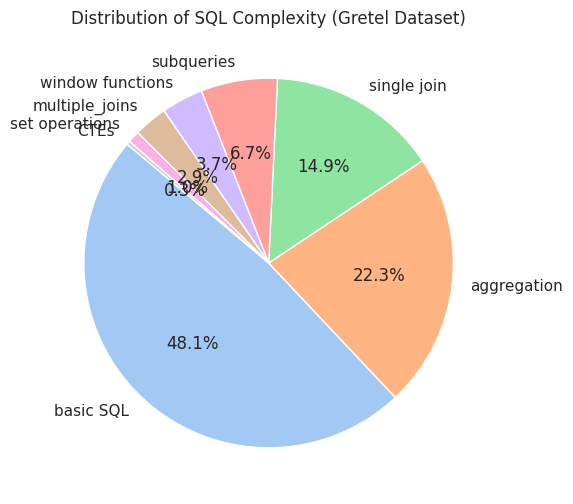

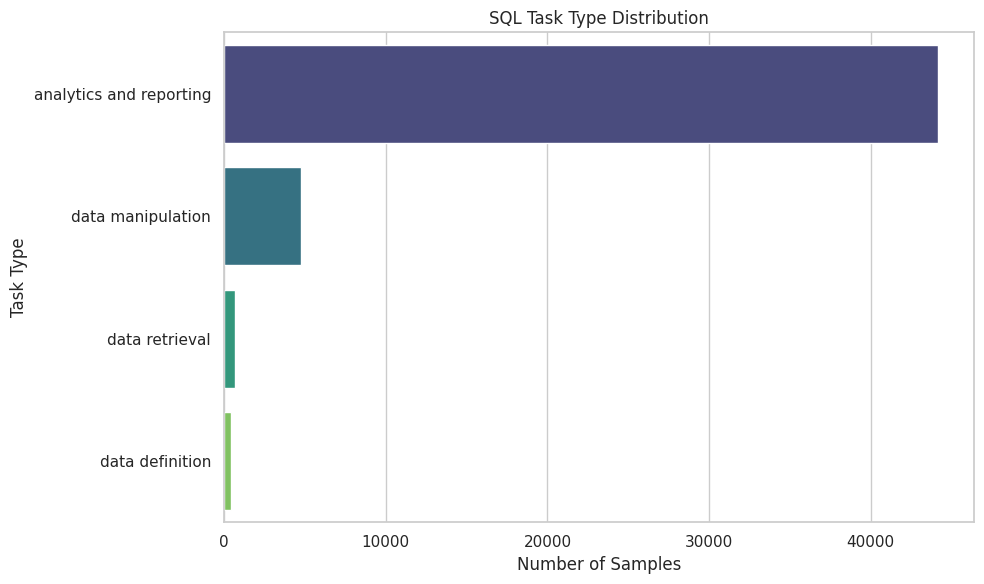

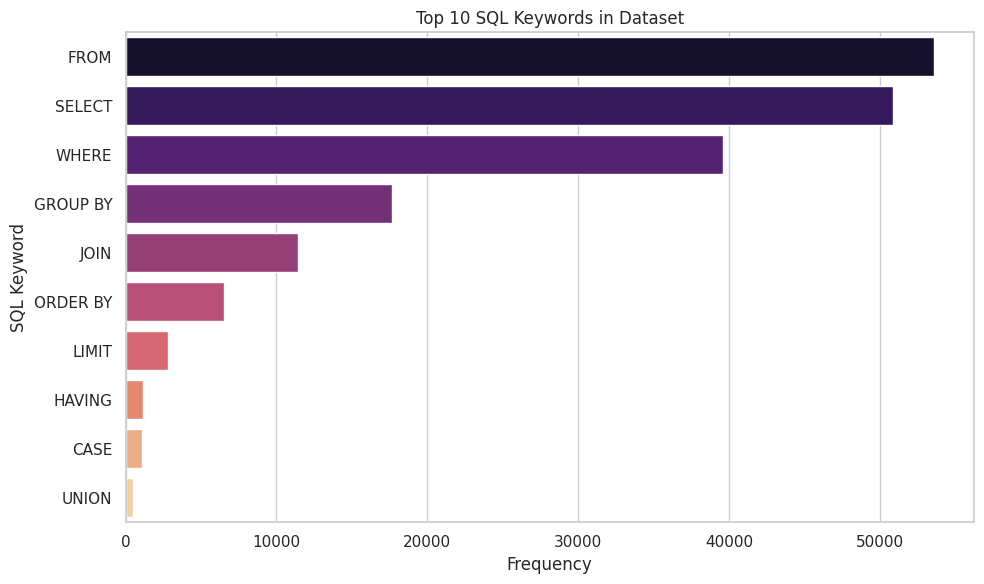

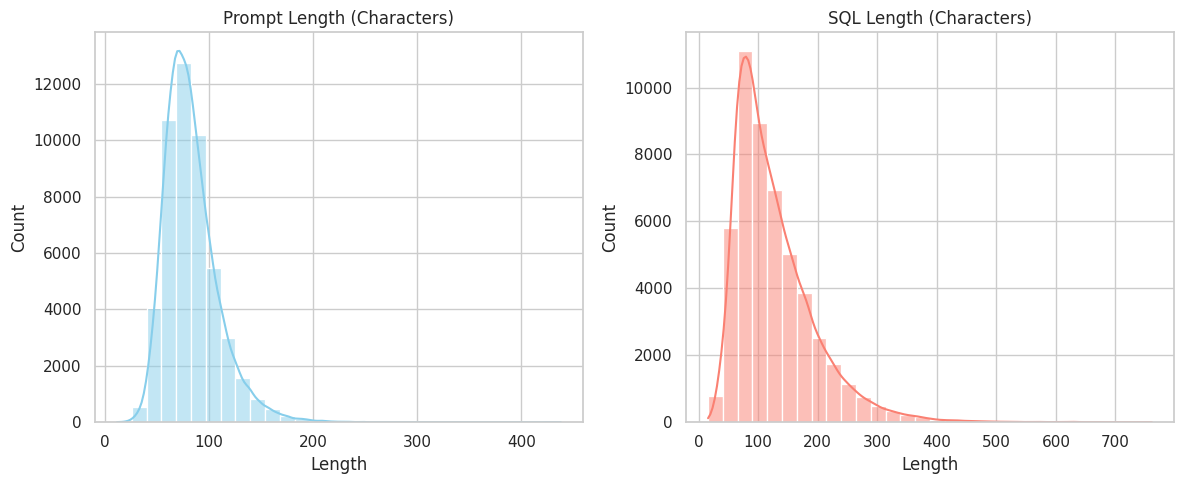

In [ ]:
# Assuming 'train_data' is your dataset object from:
# train_data = load_dataset("gretelai/synthetic_text_to_sql", split="train").select(range(10000))
# Create DataFrame from raw_subset to retain original columns for analysis
df = raw_subset.to_pandas()

# Set the visualization style
sns.set_theme(style="whitegrid")

# 1. SQL Complexity Distribution
plt.figure(figsize=(8, 6))
df['sql_complexity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Distribution of SQL Complexity (Gretel Dataset)')
plt.ylabel('')
plt.savefig('sql_complexity_pie.png')

# 2. SQL Task Type Distribution
plt.figure(figsize=(10, 6))
task_order = df['sql_task_type'].value_counts().index
sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
plt.title('SQL Task Type Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Task Type')
plt.tight_layout()
plt.savefig('task_type_bar.png')

# 3. SQL Keyword Frequency (Top 10)
def get_keywords(sql_list):
    keywords = []
    for sql in sql_list:
        # Regex to find major SQL keywords
        found = re.findall(r'\b(SELECT|FROM|JOIN|WHERE|GROUP BY|ORDER BY|LIMIT|CASE|CAST|UNION|WITH|HAVING)\b', sql.upper())
        keywords.extend(found)
    return Counter(keywords)

kw_counts = get_keywords(df['sql'].tolist())
kw_df = pd.DataFrame(kw_counts.items(), columns=['Keyword', 'Frequency']).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')
plt.title('Top 10 SQL Keywords in Dataset')
plt.xlabel('Frequency')
plt.ylabel('SQL Keyword')
plt.tight_layout()
plt.savefig('keyword_frequency.png')

# 4. Prompt vs SQL Length Distribution
df['prompt_len'] = df['sql_prompt'].apply(len)
df['sql_len'] = df['sql'].apply(len)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], bins=30, color='skyblue', kde=True)
plt.title('Prompt Length (Characters)')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
sns.histplot(df['sql_len'], bins=30, color='salmon', kde=True)
plt.title('SQL Length (Characters)')
plt.xlabel('Length')

plt.tight_layout()
plt.savefig('length_distribution.png')

# Show all plots
plt.show()

### Infrastructure Provisioning

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
%%bash
# Source gcloud environment before running installation scripts
source /root/google-cloud-sdk/path.bash.inc
source /root/google-cloud-sdk/completion.bash.inc

cd $PROJECT_DIR/setup
#chmod +x install_gcp.sh
chmod +x install_kubectl.sh
#./install_gcp.sh
./install_kubectl.sh

# Ensure gcloud SDK bin directory is in PATH for this session
export PATH=$PATH:/root/google-cloud-sdk/bin

# Verify kubectl is now accessible and gke-gcloud-auth-plugin is functional
echo "Verifying kubectl accessibility and gke-gcloud-auth-plugin:"
kubectl version --client

kubectl not found. Installing...
Client Version: v1.35.2
Kustomize Version: v5.7.1
kubectl installed successfully!
Verifying kubectl accessibility and gke-gcloud-auth-plugin:
Client Version: v1.35.2
Kustomize Version: v5.7.1


bash: line 2: /root/google-cloud-sdk/path.bash.inc: No such file or directory
bash: line 3: /root/google-cloud-sdk/completion.bash.inc: No such file or directory
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 55.8M  100 55.8M    0     0  56.0M      0 --:--:-- --:--:-- --:--:-- 56.0M


In [ ]:
project_id = config_loader.get('project.id')
location = config_loader.get('project.region')
CLUSTER_NAME=config_loader.get("gke.cluster.name")
CLUSTER_NODE_COUNT=config_loader.get("gke.cluster.num_nodes")
CLUSTER_MACHINE_TYPE=config_loader.get("gke.cluster.machine_type")
WORKLOAD_POOL_FULL=f"{project_id}.svc.id.goog"
NODEPOOL_NAME=config_loader.get("gke.node_pool.name")
NODEPOOL_MACHINE_TYPE=config_loader.get("gke.node_pool.machine_type")
ACCELERATOR_TYPE=config_loader.get("gke.node_pool.accelerator.type")
ACCELERATOR_COUNT=config_loader.get("gke.node_pool.accelerator.count")
NODEPOOL_NUM_NODES=config_loader.get("gke.node_pool.num_nodes")
SCOPES=config_loader.get("gke.node_pool.scopes")
REPOSITORY_NAME=config_loader.get("gke.node_pool.repository_name")
GCP_SERVICE_ACCOUNT=config_loader.get("GCP_SERVICE_ACCOUNT")


# Ensure the script is executable
!chmod +x {project_dir}/setup/create_gke_cluster.sh

# Construct the command string and execute in a single bash shell
command_str = f"""
\"{project_dir}/setup/create_gke_cluster.sh\" \
  \"{CLUSTER_NAME}\" \
  \"{project_id}\" \
  \"{location}\" \
  \"{CLUSTER_MACHINE_TYPE}\" \
  \"{CLUSTER_NODE_COUNT}\" \
  \"{WORKLOAD_POOL_FULL}\" \
  \"{NODEPOOL_NAME}\" \
  \"{NODEPOOL_MACHINE_TYPE}\" \
  \"{ACCELERATOR_TYPE}\" \
  \"{ACCELERATOR_COUNT}\" \
  \"{NODEPOOL_NUM_NODES}\" \
  \"{SCOPES}\" \
  \"{REPOSITORY_NAME}\" \
  \"{GCP_SERVICE_ACCOUNT}\" \
"""

!bash -c "{command_str}"

Checking for existing GKE cluster: sdk-training-cluster in us-central1-b
GKE cluster sdk-training-cluster already exists.
Fetching cluster endpoint and auth data.
CRITICAL: ACTION REQUIRED: gke-gcloud-auth-plugin, which is needed for continued use of kubectl, was not found or is not executable. Install gke-gcloud-auth-plugin for use with kubectl by following https://cloud.google.com/kubernetes-engine/docs/how-to/cluster-access-for-kubectl#install_plugin
kubeconfig entry generated for sdk-training-cluster.
Checking for node pool: gpu-pool
Node pool already exists.
Repository exists.
Infrastructure setup complete.


In [ ]:
import os
import re
import textwrap

def clean_output(output):
    text = "".join(output).strip()
    # Remove ANSI escape codes and any non-printable control characters
    text = re.sub(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])', '', text)
    return "".join(char for char in text if char.isprintable())

# 1. Get the Access Token
auth_token = !gcloud auth print-access-token
token = clean_output(auth_token)

location = 'us-central1-b'
project_id = config_loader.get('project.id')
CLUSTER_NAME=config_loader.get("gke.cluster.name")

# 2. Get Cluster Endpoint and CA Cert (using the corrected zone)
gke_endpoint = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(endpoint)"
gke_ca_cert = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(masterAuth.clusterCaCertificate)"

endpoint = clean_output(gke_endpoint)
ca_cert = clean_output(gke_ca_cert)

# 3. Build the config using dedent to guarantee no hidden tabs or leading spaces
kubeconfig = textwrap.dedent(f"""
apiVersion: v1
kind: Config
clusters:
- cluster:
    certificate-authority-data: {ca_cert}
    server: https://{endpoint}
  name: gke-cluster
contexts:
- context:
    cluster: gke-cluster
    user: colab-user
  name: gke-context
current-context: gke-context
users:
- name: colab-user
  user:
    token: {token}
""").strip()

# 4. Write and verify
with open("/content/kubeconfig.yaml", "w") as f:
    f.write(kubeconfig)

os.environ['KUBECONFIG'] = '/content/kubeconfig.yaml'

# Check for tabs specifically (will print nothing if clean)
!grep -P '\t' /content/kubeconfig.yaml && echo "Error: Tabs found in YAML!"

print("Kubeconfig generated! Testing connection...")
!kubectl get nodes

Kubeconfig generated! Testing connection...
NAME                                                  STATUS   ROLES    AGE   VERSION
gke-sdk-training-cluster-default-pool-295ba054-mff6   Ready    <none>   3h    v1.34.4-gke.1047000


In [ ]:
!kubectl create serviceaccount gemma-training-job-ksa

serviceaccount/gemma-training-job-ksa created


In [ ]:
!gcloud projects add-iam-policy-binding "${GOOGLE_CLOUD_PROJECT}" \
    --member="serviceAccount:${GCP_SERVICE_ACCOUNT}" \
    --role="roles/editor" \
    --condition="None"

In [ ]:
gcp_service_account = os.getenv("GCP_SERVICE_ACCOUNT")
gcs_bucket = config_loader.get('data.gcs_bucket')

!gcloud storage buckets add-iam-policy-binding gs://{gcs_bucket} \
  --member="serviceAccount:{gcp_service_account}" \
  --role="roles/storage.objectViewer"

print(f"Granted roles/storage.objectViewer to {gcp_service_account} for bucket {gcs_bucket}")

In [ ]:
!gcloud iam service-accounts add-iam-policy-binding \
    "${GCP_SERVICE_ACCOUNT}" \
    --role="roles/iam.workloadIdentityUser" \
    --member="serviceAccount:${GOOGLE_CLOUD_PROJECT}.svc.id.goog[default/gemma-training-job-ksa]"

In [ ]:
!kubectl annotate serviceaccount gemma-training-job-ksa \
    iam.gke.io/gcp-service-account=${os.getenv('GCP_SERVICE_ACCOUNT')} --overwrite

serviceaccount/gemma-training-job-ksa annotated


In [ ]:
# Check if the secret already exists and delete it to ensure a clean creation
!kubectl get secret training-secrets &> /dev/null && kubectl delete secret training-secrets

# Create the Kubernetes secret
!kubectl create secret generic training-secrets --from-literal=HF_TOKEN=$HF_TOKEN

secret/training-secrets created


In [ ]:
HF_TOKEN = config_loader.get('hf_token')
project_id = config_loader.get('project.id')
gcs_bucket = config_loader.get('data.gcs_bucket')
gcs_mount_path = f"/gcs/{gcs_bucket}"
repository_name = config_loader.get('gke.node_pool.repository_name')
ml_image_name = config_loader.get('gke.node_pool.ml_image_name')
ml_image_name='gemma_training'
ml_image_path = f"us-central1-docker.pkg.dev/{project_id}/{repository_name}/{ml_image_name}:latest"

os.environ['ML_IMAGE_PATH'] = ml_image_path
os.environ['ML_IMAGE_NAME'] = ml_image_name

In [ ]:
configmap_yaml_content = f"""apiVersion: v1
kind: ConfigMap
metadata:
  name: gemma-perf-config
data:
  GCP_PROJECT_ID_CM: "{project_id}"
  GCS_BUCKET_CM: "{gcs_bucket}"
  GCS_MOUNT_PATH: "{gcs_mount_path}"
"""

configmap_yaml_path = f"{project_dir}/job/gemma-perf-config.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

print(f"Kubernetes ConfigMap YAML for gemma-perf-config created at: {configmap_yaml_path}")

Kubernetes ConfigMap YAML for gemma-perf-config created at: /content/aai-590-tinysql/job/gemma-perf-config.yaml


In [ ]:
configmap_yaml_path = f"{project_dir}/job/gemma-perf-config.yaml"
!kubectl apply -f {configmap_yaml_path}
print(f"Kubernetes ConfigMap {configmap_yaml_path} applied.")

configmap/gemma-perf-config created
Kubernetes ConfigMap /content/aai-590-tinysql/job/gemma-perf-config.yaml applied.


In [ ]:
script_template_path=f"{project_dir}/job/gemma_job_template.yaml"
script_template = ""
with open(script_template_path, "r") as f:
    script_template = f.read()

# Load the YAML template into a Python dictionary
base_job_script = yaml.safe_load(script_template)
base_job_script['spec']['template']['spec']['containers'][0]['image'] = ml_image_path


In [ ]:
command_str = "python3 src/model_training/gemma_vanilla_model_perf.py           --model_id 'google/gemma-3-4b-it'"

# Create a deep copy of base_job_script to ensure it remains immutable
perf_benchmark_job_dict = copy.deepcopy(base_job_script)

# Update the args in the appropriate location in the dictionary
perf_benchmark_job_dict['spec']['template']['spec']['containers'][0]['args'] = [command_str]
perf_benchmark_job_dict['spec']['template']['spec']['containers'][0]['volumeMounts'][1]['mountPath'] = f"/gcs/{gcs_bucket}"


# Convert the dictionary back to a YAML string
perf_benchmark_job = yaml.dump(perf_benchmark_job_dict, sort_keys=False)


In [ ]:
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla_perf.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

In [ ]:
# Define the output directory and file path
output_dir = os.path.join(os.environ['PROJECT_DIR'], 'data')
train_output_file_path = os.path.join(output_dir, 'tinycode_train_ds.jsonl')
test_output_file_path = os.path.join(output_dir, 'tinycode_test_ds.jsonl')

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the dataset to a JSON Lines file
tinycode_train_ds.to_json(train_output_file_path)
tinycode_test_ds.to_json(test_output_file_path)

print(f"Dataset saved to: {train_output_file_path}")
print(f"Dataset saved to: {test_output_file_path}")

Creating json from Arrow format:   0%|          | 0/50 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Dataset saved to: /content/aai-590-tinysql/data/tinycode_train_ds.jsonl
Dataset saved to: /content/aai-590-tinysql/data/tinycode_test_ds.jsonl


In [ ]:
!gsutil cp {train_output_file_path} gs://{gcs_bucket}/data/tinycode_train_ds.jsonl
!gsutil cp {test_output_file_path} gs://{gcs_bucket}/data/tinycode_test_ds.jsonl

print(f"Dataset uploaded to gs://{gcs_bucket}/data/tinycode_train_ds.jsonl")

Copying file:///content/aai-590-tinysql/data/tinycode_train_ds.jsonl [Content-Type=application/octet-stream]...
- [1 files][ 58.9 MiB/ 58.9 MiB]                                                
Operation completed over 1 objects/58.9 MiB.                                     
Copying file:///content/aai-590-tinysql/data/tinycode_test_ds.jsonl [Content-Type=application/octet-stream]...
/ [1 files][  5.6 MiB/  5.6 MiB]                                                
Operation completed over 1 objects/5.6 MiB.                                      
Dataset uploaded to gs://cfpb-raw-lake-sdk/data/tinycode_train_ds.jsonl


#### Image Creation

In [ ]:
%%bash
# Build and push the Docker image to Google Artifact Registry

# Ensure the script stops if any command fails
set -e

# Navigate to the project directory
cd $PROJECT_DIR

# Build the Docker image and tag it
echo "Building Docker image: " $ML_IMAGE_PATH
gcloud builds submit . --tag $ML_IMAGE_PATH

echo "Docker image build and push complete."

In [ ]:
from google.colab import files
files.download('/content/aai-590-tinysql.zip')

In [ ]:
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla-perf.yaml"
with open(gemma_vanilla_perf_yaml_path, "w") as f:
    f.write(perf_benchmark_job)

print(f"Kubernetes job configuration saved to: {gemma_vanilla_perf_yaml_path}")


Kubernetes job configuration saved to: /content/aai-590-tinysql/job/gemma-vanilla-perf.yaml


In [ ]:
import time
import shlex

def wait_for_pod_and_exec(job_name):
    """
    Waits for a Kubernetes pod associated with a given job to be in a 'Running' state
    and then opens an interactive shell session to it.

    Args:
        job_name (str): The name of the Kubernetes job.
    """
    # Construct the command string safely to get the pod name
    get_pod_name_cmd = f"kubectl get pods -l job-name={shlex.quote(job_name)} -o=jsonpath='{{.items[0].metadata.name}}'"
    pods_output = !bash -c "{get_pod_name_cmd}"

    # Assuming the output is a list, and the first element is the pod name
    pod_name = pods_output[0].strip() if pods_output and pods_output[0].strip() else ""

    if not pod_name:
        print(f"No pod found for job {job_name}. Command output: {pods_output}")
        return
    else:
        print(f"Found pod: {pod_name}")

        # Wait for the pod to be in Running state
        print(f"Waiting for pod {pod_name} to be in 'Running' status...")
        while True:
            # Construct the command string safely to get the pod status
            get_status_cmd = f"kubectl get pod {shlex.quote(pod_name)} -o=jsonpath='{{.status.phase}}'"
            status_output = !bash -c "{get_status_cmd}"

            if status_output and status_output[0].strip():
                pod_status = status_output[0].strip()
            else:
                pod_status = "Unknown" # Handle cases where output is empty or command fails

            print(f"Current status: {pod_status}")
            if pod_status == 'Running':
                print(f"Pod {pod_name} is now Running!")
                break
            elif pod_status in ['Pending', 'ContainerCreating', 'Init:0/1']:
                print(f"Pod {pod_name} is still {pod_status}. Waiting...")
                time.sleep(10) # Wait 10 seconds before checking again
            else:
                print(f"Pod {pod_name} entered an unexpected state: {pod_status}. Exiting.")
                return

        # Open an interactive shell session
        if pod_status == 'Running':
            print(f"Opening interactive shell session to {pod_name}...")
            # Construct the command string safely for kubectl exec
            exec_cmd = f"kubectl exec -it {shlex.quote(pod_name)} -- bash"
            !bash -c "{exec_cmd}"
        else:
            print("Cannot open shell: Pod is not in 'Running' state.")

# Example usage:
# job_name_to_check = "gemma-vanilla-perf-job"
# wait_for_pod_and_exec(job_name_to_check)


In [ ]:
import os
import re
import textwrap

def clean_output(output):
    text = "".join(output).strip()
    # Remove ANSI escape codes and any non-printable control characters
    text = re.sub(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])', '', text)
    return "".join(char for char in text if char.isprintable())

# 1. Get the Access Token
auth_token = !gcloud auth print-access-token
token = clean_output(auth_token)

location = 'us-central1-b'
project_id = config_loader.get('project.id')
CLUSTER_NAME=config_loader.get("gke.cluster.name")

# 2. Get Cluster Endpoint and CA Cert (using the corrected zone)
gke_endpoint = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(endpoint)"
gke_ca_cert = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(masterAuth.clusterCaCertificate)"

endpoint = clean_output(gke_endpoint)
ca_cert = clean_output(gke_ca_cert)

# 3. Build the config using dedent to guarantee no hidden tabs or leading spaces
kubeconfig = textwrap.dedent(f"""
apiVersion: v1
kind: Config
clusters:
- cluster:
    certificate-authority-data: {ca_cert}
    server: https://{endpoint}
  name: gke-cluster
contexts:
- context:
    cluster: gke-cluster
    user: colab-user
  name: gke-context
current-context: gke-context
users:
- name: colab-user
  user:
    token: {token}
""").strip()

# 4. Write and verify
with open("/content/kubeconfig.yaml", "w") as f:
    f.write(kubeconfig)

os.environ['KUBECONFIG'] = '/content/kubeconfig.yaml'

# Check for tabs specifically (will print nothing if clean)
!grep -P '\t' /content/kubeconfig.yaml && echo "Error: Tabs found in YAML!"

print("Kubeconfig generated! Testing connection...")
!kubectl get nodes

Kubeconfig generated! Testing connection...
NAME                                                  STATUS   ROLES    AGE    VERSION
gke-sdk-training-cluster-default-pool-295ba054-mff6   Ready    <none>   134m   v1.34.4-gke.1047000
gke-sdk-training-cluster-gpu-pool-226a6847-w2xc       Ready    <none>   42m    v1.34.4-gke.1047000


In [ ]:
%%bash
export GCS_BUCKET=$(kubectl get configmap gemma-perf-config -o jsonpath='{.data.GCS_BUCKET_CM}')
echo $GCS_BUCKET
envsubst < ${PROJECT_DIR}/job/gemma-vanilla-perf.yaml | kubectl apply -f -

cfpb-raw-lake-sdk
job.batch/gemma-vanilla-perf-job created


### Backup

In [ ]:
%%bash
zip -r /content/aai-590-tinysql.zip /content/aai-590-tinysql

echo "Zip file created at /content/aai-590-tinysql.zip"

  adding: content/aai-590-tinysql/ (stored 0%)
  adding: content/aai-590-tinysql/Dockerfile (deflated 36%)
  adding: content/aai-590-tinysql/setup/ (stored 0%)
  adding: content/aai-590-tinysql/setup/install_gcp.sh (deflated 56%)
  adding: content/aai-590-tinysql/setup/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-590-tinysql/setup/create_gke_cluster.sh (deflated 66%)
  adding: content/aai-590-tinysql/setup/install_kubectl.sh (deflated 50%)
  adding: content/aai-590-tinysql/env.txt (deflated 22%)
  adding: content/aai-590-tinysql/config/ (stored 0%)
  adding: content/aai-590-tinysql/config/config.yaml (deflated 54%)
  adding: content/aai-590-tinysql/config/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-590-tinysql/src/ (stored 0%)
  adding: content/aai-590-tinysql/src/model_training/ (stored 0%)
  adding: content/aai-590-tinysql/src/model_training/perf_testing.py (deflated 62%)
  adding: content/aai-590-tinysql/src/model_training/.ipynb_checkpoints/ (stored 0%)
  adding: